# Celda 1 — Montar Drive e imports


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = '/content/drive/MyDrive/project_factoria/waste_classifier'
UNIFIED     = os.path.join(BASE_PATH, 'datasets/unified')
METADATA    = os.path.join(BASE_PATH, 'datasets/metadata')
CHECKPOINTS = os.path.join(BASE_PATH, 'checkpoints')
LOGS        = os.path.join(BASE_PATH, 'logs')
os.makedirs(CHECKPOINTS, exist_ok=True)
os.makedirs(LOGS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Dispositivo: cpu


# Celda 2 — Cargar configuración y recrear DataLoaders

In [2]:
with open(os.path.join(METADATA, 'config.json')) as f:
    config = json.load(f)

with open(os.path.join(METADATA, 'class_weights.json')) as f:
    weights_dict = json.load(f)

IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD  = config['imagenet_std']
BATCH_SIZE    = config['batch_size']
NUM_CLASSES   = config['num_classes']

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

dataset_train = datasets.ImageFolder(os.path.join(UNIFIED, 'train'), transform=transform_train)
dataset_val   = datasets.ImageFolder(os.path.join(UNIFIED, 'val'),   transform=transform_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Class weights en el orden que ImageFolder asignó las clases
class_weights = torch.tensor(
    [weights_dict[c] for c in dataset_train.classes],
    dtype=torch.float
).to(device)

print("Clases en orden ImageFolder:")
for i, c in enumerate(dataset_train.classes):
    print(f"  {i} → {c:<18} weight: {weights_dict[c]:.4f}")
print(f"\nBatches train: {len(loader_train)} | Batches val: {len(loader_val)}")

Clases en orden ImageFolder:
  0 → carton             weight: 1.8548
  1 → metal              weight: 1.6525
  2 → no_reciclable      weight: 0.3292
  3 → organico           weight: 1.7776
  4 → papel              weight: 1.5186
  5 → plastico           weight: 1.4350
  6 → vidrio             weight: 1.1108

Batches train: 571 | Batches val: 72


# Celda 3 — Construir el modelo (EfficientNet-B0 con transfer learning)


In [3]:
# EfficientNet-B0: buen balance entre tamaño, velocidad y precisión
# pretrained=True carga los pesos de ImageNet — la red ya "sabe ver"
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Congelamos todo el backbone — solo entrenamos el clasificador final
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la última capa para 7 clases (originalmente tiene 1000)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# Contar parámetros
total    = sum(p.numel() for p in model.parameters())
entrena  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {entrena:,}  ({100*entrena/total:.1f}% del modelo)")
print(f"\nArquitectura del clasificador:")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 64.9MB/s]

Parámetros totales:      4,016,515
Parámetros entrenables:  8,967  (0.2% del modelo)

Arquitectura del clasificador:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


# Celda 4 — Configurar loss, optimizer y scheduler


In [4]:
NUM_EPOCHS = 15
LR_HEAD    = 1e-3   # learning rate para el clasificador nuevo

# CrossEntropyLoss con class weights — penaliza más los errores en clases minoritarias
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Solo optimizamos los parámetros del clasificador (los únicos con requires_grad=True)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=1e-4
)

# Reduce el LR a la mitad si val_loss no mejora en 3 epochs seguidas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Loss:      CrossEntropyLoss con class weights")
print(f"Optimizer: AdamW  lr={LR_HEAD}  weight_decay=1e-4")
print(f"Scheduler: ReduceLROnPlateau  factor=0.5  patience=3")
print(f"Epochs:    {NUM_EPOCHS}")

Loss:      CrossEntropyLoss con class weights
Optimizer: AdamW  lr=0.001  weight_decay=1e-4
Scheduler: ReduceLROnPlateau  factor=0.5  patience=3
Epochs:    15


# Celda 5 — Funciones de entrenamiento y validación


In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total


print("Funciones de entrenamiento definidas")

Funciones de entrenamiento definidas


# Celda 6 — Loop de entrenamiento con guardado de checkpoints

Esta celda entrena los 15 epochs. Con la T4 de Colab tarda aproximadamente 3-4 minutos por epoch, unos 50-60 minutos en total. No cierres el navegador.

In [6]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch   = 0

print(f"Iniciando entrenamiento — {NUM_EPOCHS} epochs")
print(f"{'Epoch':<7} {'T_loss':<10} {'T_acc':<10} {'V_loss':<10} {'V_acc':<10} {'Tiempo':<8} {'Estado'}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_epoch(model, loader_train, criterion, optimizer, device)
    val_loss,   val_acc   = val_epoch(model, loader_val, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    estado  = ''

    # Guardar siempre el último checkpoint
    torch.save({
        'epoch':      epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc':    val_acc,
        'val_loss':   val_loss,
        'classes':    dataset_train.classes,
        'history':    history
    }, os.path.join(CHECKPOINTS, 'last_epoch.pth'))

    # Guardar el mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        estado       = '★ mejor'
        torch.save({
            'epoch':      epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc':    val_acc,
            'val_loss':   val_loss,
            'classes':    dataset_train.classes,
            'history':    history
        }, os.path.join(CHECKPOINTS, 'best_model.pth'))

    print(f"{epoch:<7} {train_loss:<10.4f} {train_acc*100:<10.2f} {val_loss:<10.4f} {val_acc*100:<10.2f} {elapsed:<8.1f} {estado}")

print(f"\nEntrenamiento terminado")
print(f"Mejor val_acc: {best_val_acc*100:.2f}%  en epoch {best_epoch}")

Iniciando entrenamiento — 15 epochs
Epoch   T_loss     T_acc      V_loss     V_acc      Tiempo   Estado
-----------------------------------------------------------------
1       0.8459     73.13      0.5475     83.17      3619.2   ★ mejor
2       0.6379     78.05      0.5044     84.75      2251.3   ★ mejor
3       0.6049     79.16      0.4575     85.68      2269.9   ★ mejor
4       0.5908     79.28      0.4670     85.68      2587.0   
5       0.5724     80.01      0.4547     84.62      2495.7   
6       0.5760     79.81      0.4471     85.02      2556.7   
7       0.5722     79.90      0.4475     85.90      2285.5   ★ mejor
8       0.5582     80.59      0.4328     85.90      2278.8   
9       0.5562     80.64      0.4168     86.60      2286.2   ★ mejor
10      0.5607     79.85      0.4033     86.64      2259.2   ★ mejor
11      0.5523     80.16      0.4116     86.56      2222.1   
12      0.5439     80.76      0.4151     86.78      2235.4   ★ mejor
13      0.5496     80.57      0.4197 

# Celda 7 — Graficar curvas de entrenamiento


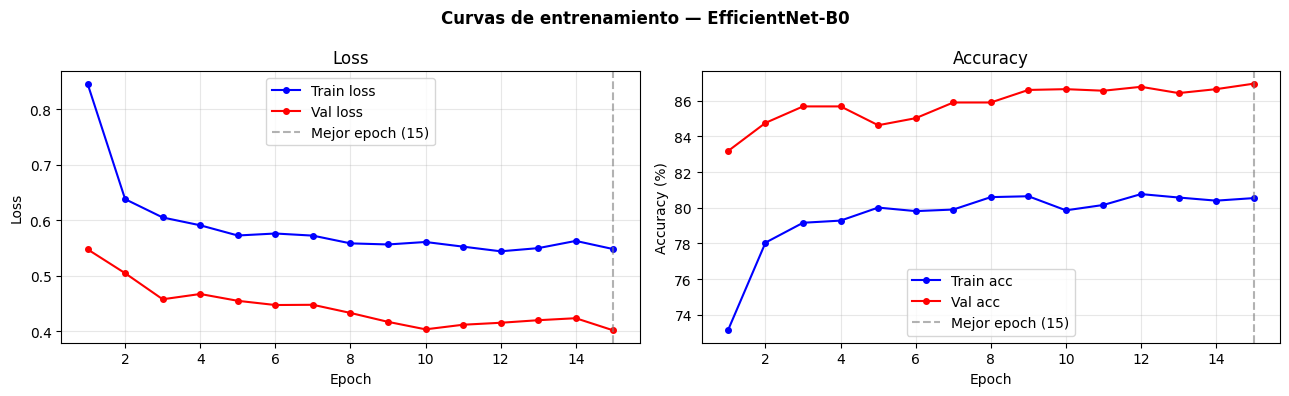

Guardado: training_curves.png


In [7]:
OUTPUTS = os.path.join(BASE_PATH, 'outputs')
epochs = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Curvas de entrenamiento — EfficientNet-B0', fontweight='bold')

axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train acc')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=4, label='Val acc')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: training_curves.png")

# Celda 8 — Guardar historial de logs


In [8]:
import csv

log_path = os.path.join(LOGS, 'train_log.csv')
with open(log_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'])
    for i, ep in enumerate(range(1, NUM_EPOCHS + 1)):
        writer.writerow([
            ep,
            round(history['train_loss'][i], 5),
            round(history['train_acc'][i],  5),
            round(history['val_loss'][i],   5),
            round(history['val_acc'][i],    5)
        ])

print(f"✓ Log guardado en {log_path}")
print(f"\nResumen final:")
print(f"  Mejor val_acc:  {best_val_acc*100:.2f}%  (epoch {best_epoch})")
print(f"  Última val_acc: {history['val_acc'][-1]*100:.2f}%")
print(f"\nNotebook 04 completo. Siguiente: 05_eval")

✓ Log guardado en /content/drive/MyDrive/project_factoria/waste_classifier/logs/train_log.csv

Resumen final:
  Mejor val_acc:  86.95%  (epoch 15)
  Última val_acc: 86.95%

Notebook 04 completo. Siguiente: 05_eval
